# EDA Interactive Notebook
## 🏦 Banking Exploratory Data Analysis — NexBank

---

### How to use this notebook
Run cells from top to bottom using **Shift+Enter**.
Each cell has a comment explaining what it does and why.

This notebook is the **interactive layer** on top of `run.py`.
While `run.py` produces text reports, this notebook produces:
- Visual charts (histograms, box plots, scatter plots, heatmaps)
- Interactive exploration of fraud patterns and segment behaviour
- Statistical test results with business interpretation

**Input:** `data/processed-data.csv`  
**Outputs:** `reports/analysis_report.txt` · `reports/anomalies.csv` · `reports/segment_profile.csv`

---

## Business Questions

### Question 1 — Fraud Patterns
Do fraudulent transactions cluster in specific merchant categories, channels, or time periods?  
Use `groupby` to find where fraud concentrates across the dataset.

> Answered by computing fraud rate per `merchant_category`, `channel`, and `transaction_date` (month/day).  
> A category or channel with fraud rate significantly above the dataset average is a priority for controls.  
> Time-period clustering may indicate organised fraud campaigns rather than opportunistic individual fraud.

---

### Question 2 — Customer Segment Behaviour
How do transaction amounts and frequencies differ across Retail, Premium, Business, and Student segments?  
Build a `SegmentProfiler` class that computes per-segment statistics including fraud rate.

> Each segment gets: mean amount, median amount, transaction count, total spend, and fraud rate.  
> A segment with high average transaction value **and** high fraud rate is the highest-risk cohort —  
> and the most costly to the business per fraudulent event.

---

### Question 3 — Chi-Square Independence Test
Are fraud rates statistically independent of `merchant_category`?  
Use `scipy.stats.chi2_contingency()` to test this formally.

> **H₀ (null hypothesis):** fraud occurrence is independent of merchant category  
> **H₁ (alternative):** fraud is more likely in certain merchant categories  
> If **p < 0.05**, the relationship is real and statistically significant — reject H₀.  
> If **p ≥ 0.05**, the pattern may be noise — do not over-interpret the groupby results from Q1.

---

### Question 4 — Transaction Anomalies
Flag transactions that are suspicious by amount using **IQR + Z-score consensus**.  
Also flag the inverse: transactions marked `is_fraud = True` but with a normal amount.

> Standard anomaly detection catches high-value outliers — easy fraud to spot.  
> The harder problem is low-value fraud that blends into normal spend patterns.  
> Flagging `is_fraud = True` rows with a normal amount (`z_score < 2`) isolates  
> the most evasive fraud — the type most likely to bypass automated rules engines.  
> Results saved to `reports/anomalies.csv` with an `anomaly_type` column distinguishing both groups.


In [15]:
# ── Cell 1: Imports and Setup ─────────────────────────────────────────────
# Before anything else, we import the libraries we need.
# These are the standard imports for any EDA notebook.

import sys
import pathlib
import numpy as np

# Add the project root to Python path so we can import our classes
# pathlib.Path.cwd() returns the current working directory
# We walk up until we find config.py
_root = pathlib.Path.cwd()
while not (_root / 'config.py').exists() and _root != _root.parent:
    _root = _root.parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt   # matplotlib: the core Python plotting library
import seaborn as sns             # seaborn: statistical plots built on matplotlib
from src.eda_engine import EDAEngine, SegmentProfiler
from scipy.stats import chi2_contingency


# Tell matplotlib to display plots directly in the notebook (not in a separate window)



# Set seaborn style: 'whitegrid' adds a subtle grid which makes values easier to read
sns.set_style('whitegrid')

# Set figure size default: (width_inches, height_inches)
plt.rcParams['figure.figsize'] = (12, 5)

# Import our pipeline classes
from config import DATA_PATH, REPORTS_DIR, INDUSTRY
from src.eda_engine import EDAEngine
from src.anomaly_detector import AnomalyDetector
print(f'Setup complete. Industry: {INDUSTRY}')
print(f'Data file: {DATA_PATH}')


Setup complete. Industry: banking
Data file: /Users/samueladesina/banking-eda/data/processed-data.csv


In [7]:
# ── Cell 2: Load and Profile the Data ────────────────────────────────────
# We use our EDAEngine class to load and profile the data.
# This is the same code that run.py executes — but here we can
# inspect intermediate results interactively.

engine = EDAEngine()
engine.load().profile()

# Access the profile results dictionary directly
p = engine.results['profile']

print('=' * 50)
print('  DATASET OVERVIEW')
print('=' * 50)
print(f'  Rows:          {p["rows"]:,}')
print(f'  Columns:       {p["columns"]}')
print(f'  Numeric cols:  {p["numeric_cols"]}')
print(f'  Text cols:     {p["categorical_cols"]}')
print(f'  Missing vals:  {p["total_nulls"]:,} ({p["null_pct"]}%)')
print(f'  Memory:        {p["memory_mb"]} MB')

2026-05-20 03:31:21 [INFO] EDAEngine initialised — industry: banking
2026-05-20 03:31:21 [INFO] [EDA] Loading: processed-data.csv
2026-05-20 03:31:22 [INFO] [EDA] Loaded 50,102 rows × 47 columns
2026-05-20 03:31:22 [INFO] [EDA] Column types: 13 numeric, 24 categorical
2026-05-20 03:31:22 [INFO] [EDA] Computing dataset profile...
2026-05-20 03:31:23 [INFO] [EDA] Profile complete — 50,102 rows | 0.0% nulls


  DATASET OVERVIEW
  Rows:          50,102
  Columns:       47
  Numeric cols:  13
  Text cols:     24
  Missing vals:  0 (0.0%)
  Memory:        88.58 MB


In [8]:
# ── Cell 3: Descriptive Statistics ───────────────────────────────────────
# pandas .describe() gives us the 8 key statistics for every numeric column.
# We display it as a formatted table directly in the notebook.

# Select only columns that are not pipeline metadata (starting with _)
analysis_df = engine.df.drop(
    columns=[c for c in engine.df.columns if c.startswith('_')],
    errors='ignore'
)

# .describe() → count, mean, std, min, 25%, 50%, 75%, max for each numeric col
# .T transposes the table: columns become rows (easier to read with many columns)
# .style.background_gradient() adds colour — higher values are darker blue
desc = analysis_df.describe().round(2).T
desc

,count,mean,std,min,25%,50%,75%,max
transaction_id,50102.0,24998.92,14437.68,1.00,12493.25,24995.50,37504.75,50006.00
amount,50102.0,246.93,8946.40,-469.31,19.73,54.74,150.95,999999.00
balance_after,50102.0,24995.42,14462.23,0.44,12478.37,24983.41,37506.42,49999.71
account_id,50102.0,4987.36,2888.29,1.00,2481.00,4988.00,7481.00,10000.00
current_balance,50102.0,124255.13,72685.41,-999999.00,62265.23,125458.91,185415.94,249980.73
account_interest_rate,50102.0,0.02,0.01,0.00,0.01,0.02,0.03,0.04
customer_id,50102.0,3983.72,2308.74,1.00,1993.00,3978.00,5981.00,8000.00
credit_score,50102.0,572.00,157.69,300.00,433.00,572.00,705.00,850.00
loan_id,50102.0,5945.63,2742.33,3.00,4762.00,5947.00,7144.00,11997.00
principal,50102.0,256093.75,115213.14,5544.26,206400.58,259071.68,310626.26,499695.26


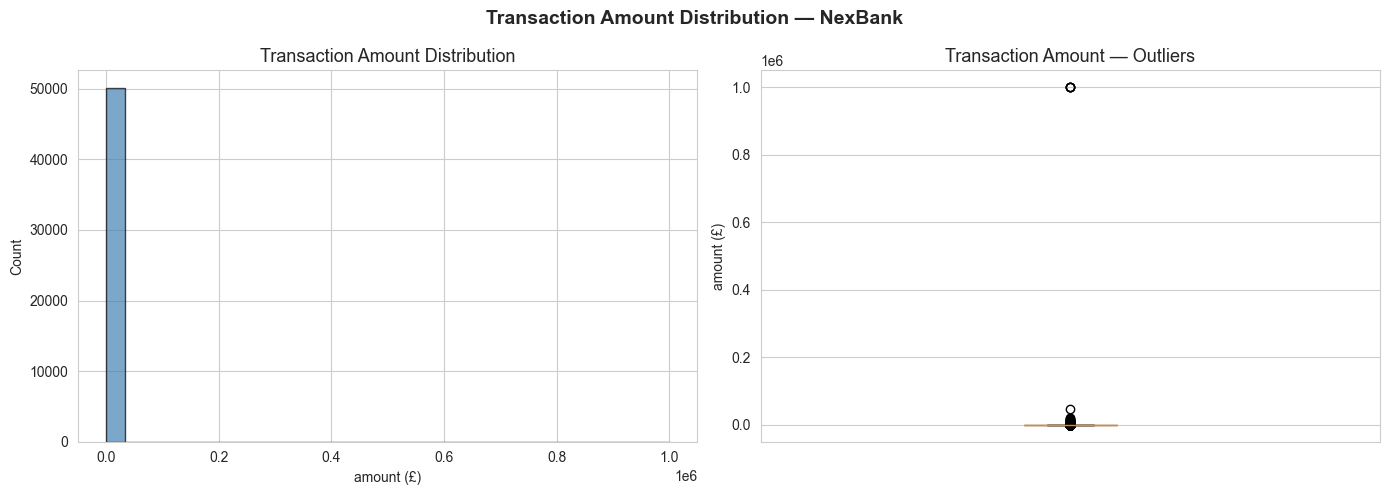

Saved → reports/dist_amount.png


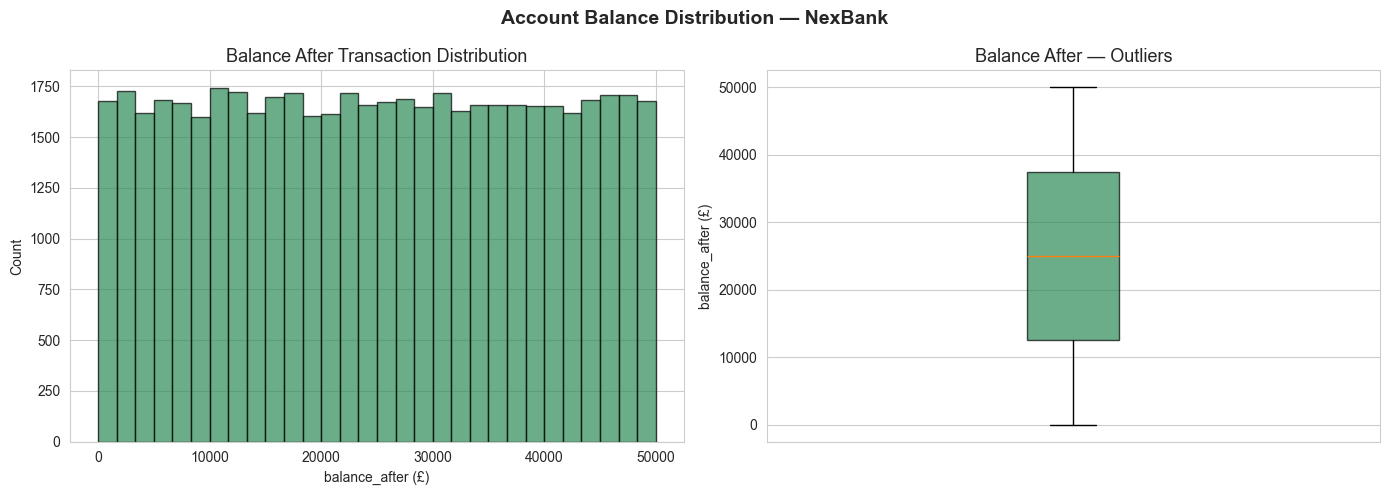

Saved → reports/dist_balance_after.png


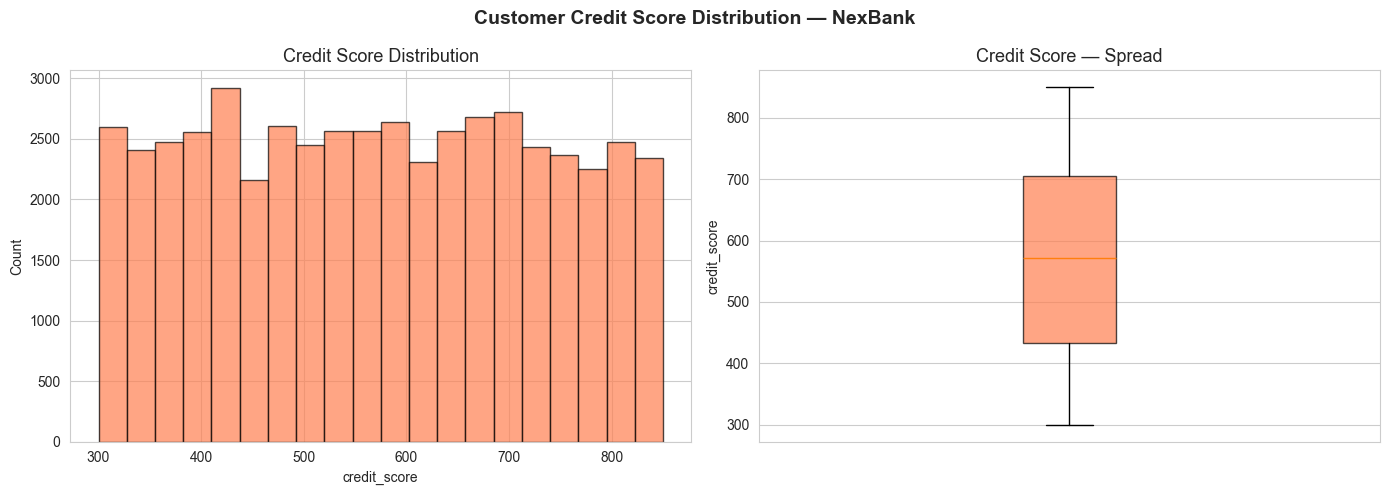

Saved → reports/dist_credit_score.png


In [9]:
# ── Transaction Amount Distribution — Histogram & Boxplot ────────────────
if 'amount' in analysis_df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].hist(
        analysis_df['amount'].dropna(),
        bins=30,
        color='steelblue',
        alpha=0.7,
        edgecolor='black'
    )
    axes[0].set_title('Transaction Amount Distribution', fontsize=13)
    axes[0].set_xlabel('amount (£)')
    axes[0].set_ylabel('Count')

    axes[1].boxplot(
        analysis_df['amount'].dropna(),
        vert=True,
        patch_artist=True,
        boxprops=dict(facecolor='steelblue', alpha=0.7)
    )
    axes[1].set_title('Transaction Amount — Outliers', fontsize=13)
    axes[1].set_ylabel('amount (£)')
    axes[1].set_xticks([])

    plt.suptitle('Transaction Amount Distribution — NexBank', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(REPORTS_DIR / 'dist_amount.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved → reports/dist_amount.png')


# ── Balance After Transaction — Histogram & Boxplot ───────────────────────
if 'balance_after' in analysis_df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].hist(
        analysis_df['balance_after'].dropna(),
        bins=30,
        color='seagreen',
        alpha=0.7,
        edgecolor='black'
    )
    axes[0].set_title('Balance After Transaction Distribution', fontsize=13)
    axes[0].set_xlabel('balance_after (£)')
    axes[0].set_ylabel('Count')

    axes[1].boxplot(
        analysis_df['balance_after'].dropna(),
        vert=True,
        patch_artist=True,
        boxprops=dict(facecolor='seagreen', alpha=0.7)
    )
    axes[1].set_title('Balance After — Outliers', fontsize=13)
    axes[1].set_ylabel('balance_after (£)')
    axes[1].set_xticks([])

    plt.suptitle('Account Balance Distribution — NexBank', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(REPORTS_DIR / 'dist_balance_after.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved → reports/dist_balance_after.png')


# ── Credit Score Distribution — Histogram & Boxplot ──────────────────────
if 'credit_score' in analysis_df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].hist(
        analysis_df['credit_score'].dropna(),
        bins=20,
        color='coral',
        alpha=0.7,
        edgecolor='black'
    )
    axes[0].set_title('Credit Score Distribution', fontsize=13)
    axes[0].set_xlabel('credit_score')
    axes[0].set_ylabel('Count')

    axes[1].boxplot(
        analysis_df['credit_score'].dropna(),
        vert=True,
        patch_artist=True,
        boxprops=dict(facecolor='coral', alpha=0.7)
    )
    axes[1].set_title('Credit Score — Spread', fontsize=13)
    axes[1].set_ylabel('credit_score')
    axes[1].set_xticks([])

    plt.suptitle('Customer Credit Score Distribution — NexBank', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(REPORTS_DIR / 'dist_credit_score.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved → reports/dist_credit_score.png')

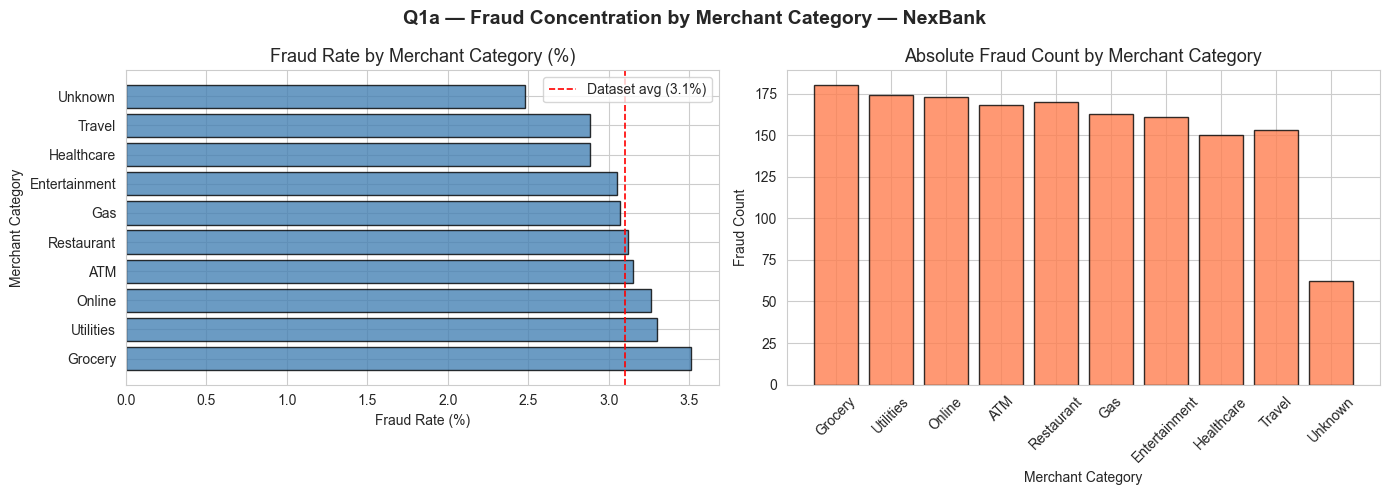

Saved → reports/fraud_by_merchant_category.png
merchant_category  fraud_count  total  fraud_rate_pct
          Grocery          180   5125            3.51
        Utilities          174   5275            3.30
           Online          173   5304            3.26
              ATM          168   5331            3.15
       Restaurant          170   5444            3.12
              Gas          163   5316            3.07
    Entertainment          161   5287            3.05
       Healthcare          150   5208            2.88
           Travel          153   5308            2.88
          Unknown           62   2504            2.48


In [10]:

# ── Q1a: Fraud rate by merchant category ─────────────────────────────────
if 'merchant_category' in analysis_df.columns and 'is_fraud' in analysis_df.columns:
    fraud_by_cat = (
        analysis_df.groupby('merchant_category')['is_fraud']
        .agg(fraud_count='sum', total='count')
        .reset_index()
    )
    fraud_by_cat['fraud_rate_pct'] = (
        fraud_by_cat['fraud_count'] / fraud_by_cat['total'] * 100
    ).round(2)
    fraud_by_cat = fraud_by_cat.sort_values('fraud_rate_pct', ascending=False)
 
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
    axes[0].barh(
        fraud_by_cat['merchant_category'],
        fraud_by_cat['fraud_rate_pct'],
        color='steelblue',
        alpha=0.8,
        edgecolor='black'
    )
    axes[0].set_title('Fraud Rate by Merchant Category (%)', fontsize=13)
    axes[0].set_xlabel('Fraud Rate (%)')
    axes[0].set_ylabel('Merchant Category')
    axes[0].axvline(
        analysis_df['is_fraud'].mean() * 100,
        color='red', linestyle='--', linewidth=1.2,
        label=f'Dataset avg ({analysis_df["is_fraud"].mean()*100:.1f}%)'
    )
    axes[0].legend(fontsize=10)
 
    axes[1].bar(
        fraud_by_cat['merchant_category'],
        fraud_by_cat['fraud_count'],
        color='coral',
        alpha=0.8,
        edgecolor='black'
    )
    axes[1].set_title('Absolute Fraud Count by Merchant Category', fontsize=13)
    axes[1].set_xlabel('Merchant Category')
    axes[1].set_ylabel('Fraud Count')
    axes[1].tick_params(axis='x', rotation=45)
 
    plt.suptitle('Q1a — Fraud Concentration by Merchant Category — NexBank',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(REPORTS_DIR / 'fraud_by_merchant_category.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved → reports/fraud_by_merchant_category.png')
    print(fraud_by_cat.to_string(index=False))
 
 


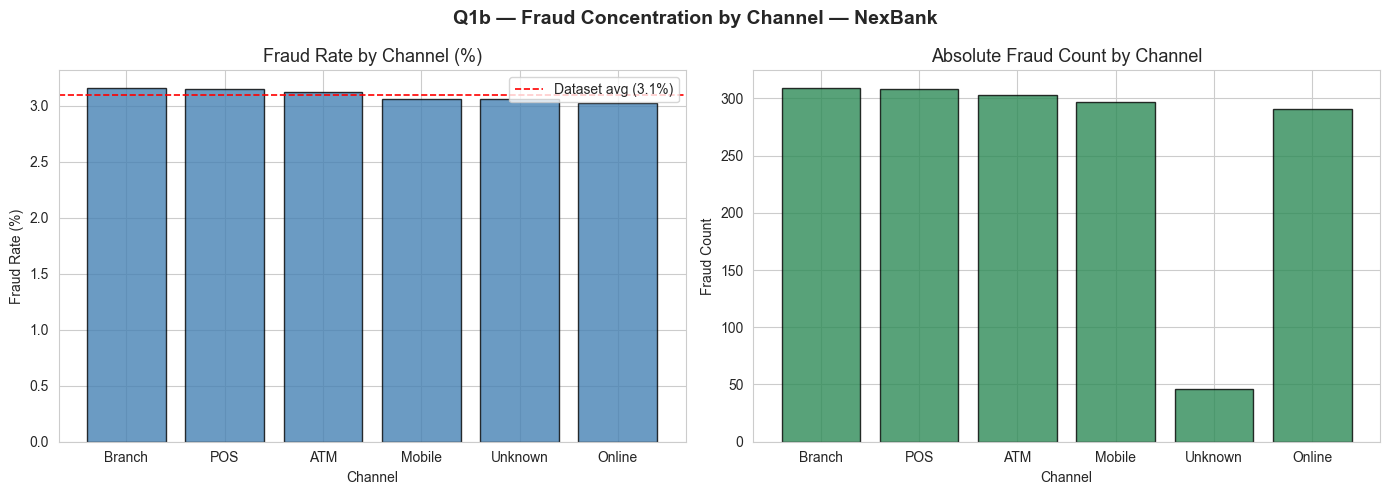

Saved → reports/fraud_by_channel.png
channel  fraud_count  total  fraud_rate_pct
 Branch          309   9791            3.16
    POS          308   9776            3.15
    ATM          303   9727            3.12
 Mobile          297   9693            3.06
Unknown           46   1503            3.06
 Online          291   9612            3.03


In [11]:
# ── Q1b: Fraud rate by channel ────────────────────────────────────────────
if 'channel' in analysis_df.columns and 'is_fraud' in analysis_df.columns:
    fraud_by_channel = (
        analysis_df.groupby('channel')['is_fraud']
        .agg(fraud_count='sum', total='count')
        .reset_index()
    )
    fraud_by_channel['fraud_rate_pct'] = (
        fraud_by_channel['fraud_count'] / fraud_by_channel['total'] * 100
    ).round(2)
    fraud_by_channel = fraud_by_channel.sort_values('fraud_rate_pct', ascending=False)
 
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
    axes[0].bar(
        fraud_by_channel['channel'],
        fraud_by_channel['fraud_rate_pct'],
        color='steelblue',
        alpha=0.8,
        edgecolor='black'
    )
    axes[0].set_title('Fraud Rate by Channel (%)', fontsize=13)
    axes[0].set_xlabel('Channel')
    axes[0].set_ylabel('Fraud Rate (%)')
    axes[0].axhline(
        analysis_df['is_fraud'].mean() * 100,
        color='red', linestyle='--', linewidth=1.2,
        label=f'Dataset avg ({analysis_df["is_fraud"].mean()*100:.1f}%)'
    )
    axes[0].legend(fontsize=10)
 
    axes[1].bar(
        fraud_by_channel['channel'],
        fraud_by_channel['fraud_count'],
        color='seagreen',
        alpha=0.8,
        edgecolor='black'
    )
    axes[1].set_title('Absolute Fraud Count by Channel', fontsize=13)
    axes[1].set_xlabel('Channel')
    axes[1].set_ylabel('Fraud Count')
 
    plt.suptitle('Q1b — Fraud Concentration by Channel — NexBank',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(REPORTS_DIR / 'fraud_by_channel.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved → reports/fraud_by_channel.png')
    print(fraud_by_channel.to_string(index=False))
 
 


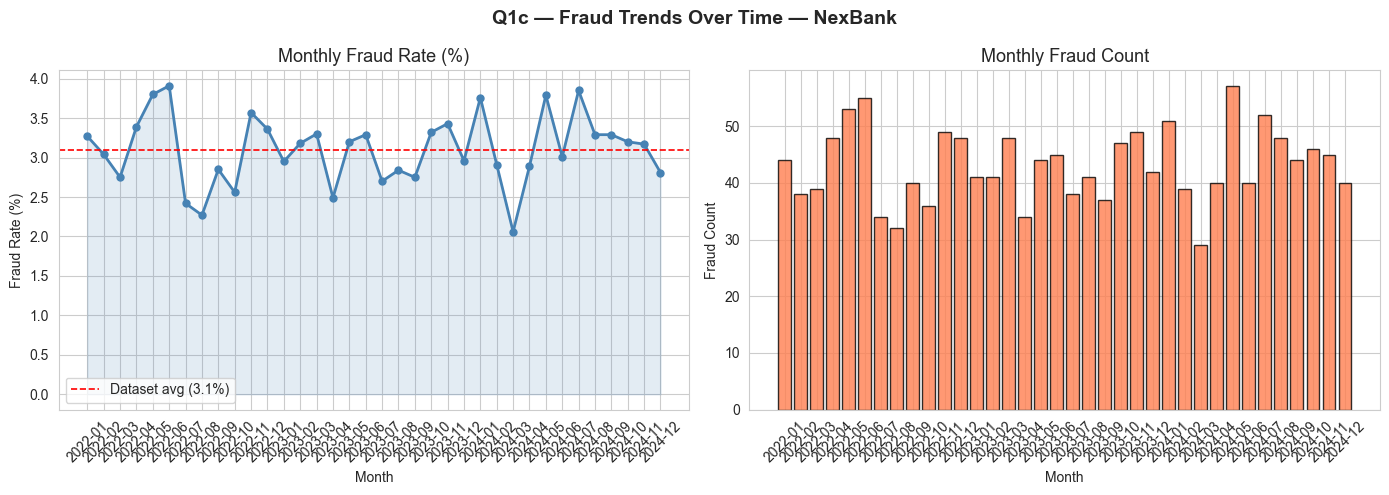

Saved → reports/fraud_by_month.png


In [12]:
# ── Q1c: Fraud rate over time ─────────────────────────────────────────────
if 'transaction_date' in analysis_df.columns and 'is_fraud' in analysis_df.columns:
    analysis_df['_month'] = pd.to_datetime(
        analysis_df['transaction_date'], errors='coerce'
    ).dt.to_period('M').astype(str)
 
    fraud_by_month = (
        analysis_df.groupby('_month')['is_fraud']
        .agg(fraud_count='sum', total='count')
        .reset_index()
    )
    fraud_by_month['fraud_rate_pct'] = (
        fraud_by_month['fraud_count'] / fraud_by_month['total'] * 100
    ).round(2)
 
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
    axes[0].plot(
        fraud_by_month['_month'],
        fraud_by_month['fraud_rate_pct'],
        color='steelblue',
        marker='o',
        linewidth=2,
        markersize=5
    )
    axes[0].fill_between(
        fraud_by_month['_month'],
        fraud_by_month['fraud_rate_pct'],
        alpha=0.15,
        color='steelblue'
    )
    axes[0].set_title('Monthly Fraud Rate (%)', fontsize=13)
    axes[0].set_xlabel('Month')
    axes[0].set_ylabel('Fraud Rate (%)')
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].axhline(
        analysis_df['is_fraud'].mean() * 100,
        color='red', linestyle='--', linewidth=1.2,
        label=f'Dataset avg ({analysis_df["is_fraud"].mean()*100:.1f}%)'
    )
    axes[0].legend(fontsize=10)
 
    axes[1].bar(
        fraud_by_month['_month'],
        fraud_by_month['fraud_count'],
        color='coral',
        alpha=0.8,
        edgecolor='black'
    )
    axes[1].set_title('Monthly Fraud Count', fontsize=13)
    axes[1].set_xlabel('Month')
    axes[1].set_ylabel('Fraud Count')
    axes[1].tick_params(axis='x', rotation=45)
 
    plt.suptitle('Q1c — Fraud Trends Over Time — NexBank',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(REPORTS_DIR / 'fraud_by_month.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved → reports/fraud_by_month.png')
 
 


2026-05-20 03:31:47 [INFO] SegmentProfiler initialised — 50,102 rows
2026-05-20 03:31:48 [INFO] [SEGMENT] Profiling by 'segment'...
2026-05-20 03:31:48 [INFO] [SEGMENT] Profiled 10 segments | highest fraud rate: Premium (3.4%)
2026-05-20 03:31:48 [INFO] [SEGMENT] Saved: /Users/samueladesina/banking-eda/reports/segment_profile.csv


Segment Analysis (10 segments)
  Highest fraud rate: Premium (3.4% | 319 cases)
  Lowest  fraud rate: PREMIUM (2.05% | 14 cases)
  Highest avg amount: BUSINESS (£1,800.96)

 segment  transaction_count  mean_amount  median_amount  total_spend  std_amount  fraud_count  fraud_rate_pct
 Premium               9377       163.50          57.13   1533176.87      375.34          319            3.40
  Retail               9140       171.72          53.41   1569477.99      507.60          290            3.17
  Senior               9670       169.18          54.74   1635990.90      491.09          304            3.14
 Student               9685       374.64          53.44   3628363.80    14380.43          289            2.98
Business               9259       274.65          54.97   2542987.34    10398.89          274            2.96
BUSINESS                613      1800.96          51.61   1103990.49    40384.39           18            2.94
  SENIOR                458       151.23          52.86  

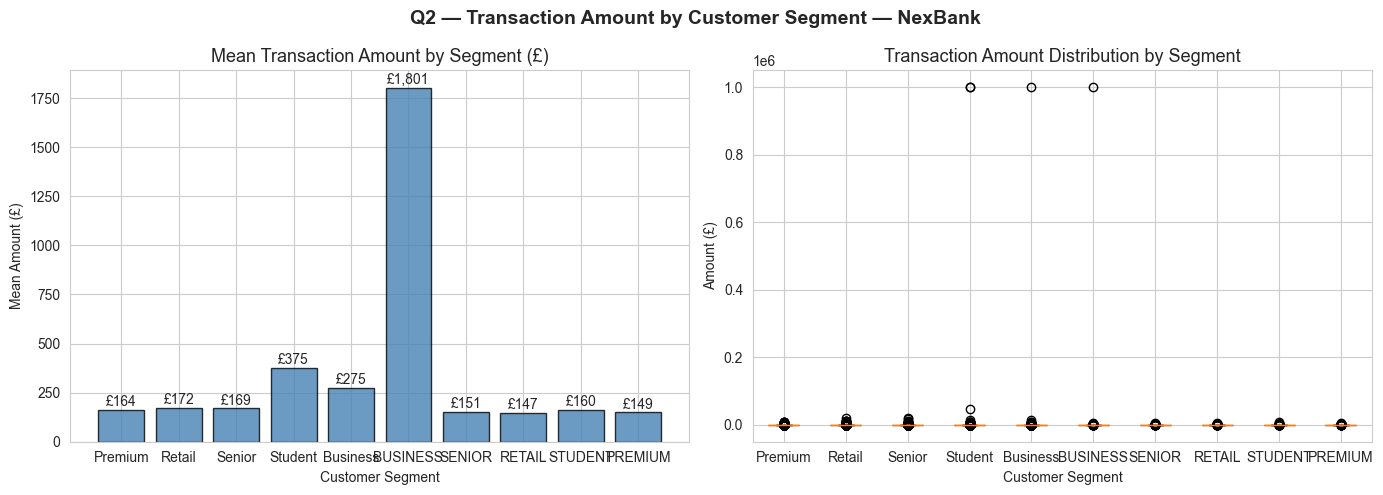

Saved → reports/segment_amount.png


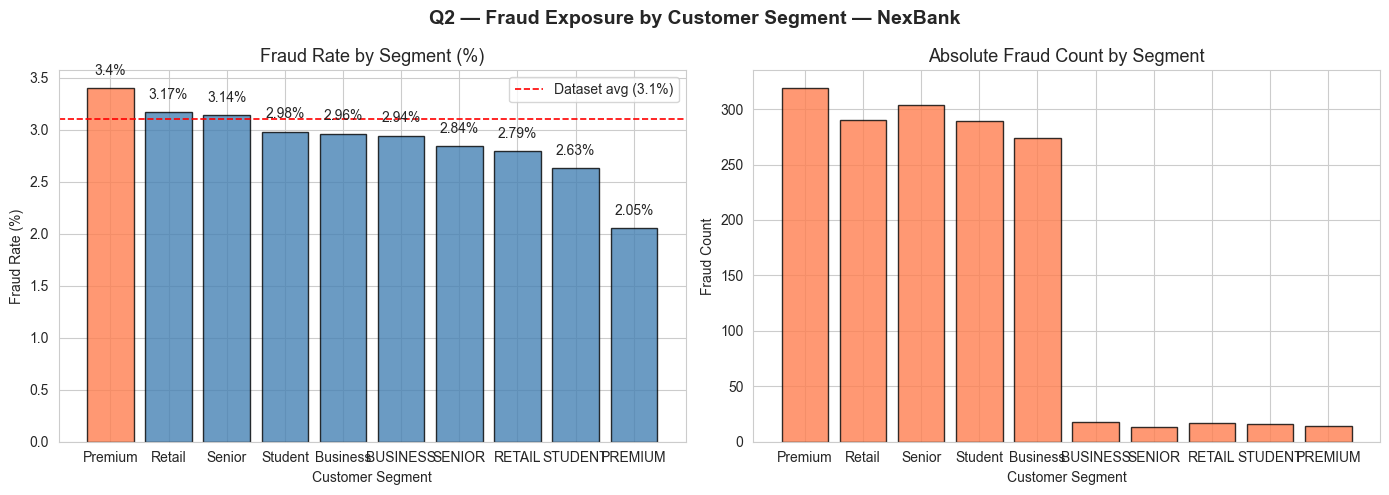

Saved → reports/segment_fraud.png


In [13]:
# ════════════════════════════════════════════════════════════════
# QUESTION 2 — CUSTOMER SEGMENT BEHAVIOUR
# How do transaction amounts and fraud rates differ across
# Retail, Premium, Business, and Student segments?
# ════════════════════════════════════════════════════════════════
 
if 'segment' in analysis_df.columns and 'amount' in analysis_df.columns:
    from src.eda_engine import SegmentProfiler
 
    profiler = SegmentProfiler(analysis_df)
    profiler.profile(
        segment_col='segment',
        amount_col='amount',
        fraud_col='is_fraud'
    )
    profiler.save(REPORTS_DIR / 'segment_profile.csv')
 
    segment_df = pd.DataFrame(profiler.results)
    print(profiler.summary())
    print()
    print(segment_df.to_string(index=False))
 
    # ── Chart 1: Mean transaction amount per segment ──────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
    axes[0].bar(
        segment_df['segment'],
        segment_df['mean_amount'],
        color='steelblue',
        alpha=0.8,
        edgecolor='black'
    )
    axes[0].set_title('Mean Transaction Amount by Segment (£)', fontsize=13)
    axes[0].set_xlabel('Customer Segment')
    axes[0].set_ylabel('Mean Amount (£)')
 
    # Add value labels on bars
    for i, row in segment_df.iterrows():
        axes[0].text(
            i, row['mean_amount'] + 5,
            f"£{row['mean_amount']:,.0f}",
            ha='center', va='bottom', fontsize=10
        )
 
    axes[1].boxplot(
        [analysis_df[analysis_df['segment'] == seg]['amount'].dropna()
         for seg in segment_df['segment']],
        labels=segment_df['segment'],
        patch_artist=True,
        boxprops=dict(facecolor='steelblue', alpha=0.6)
    )
    axes[1].set_title('Transaction Amount Distribution by Segment', fontsize=13)
    axes[1].set_xlabel('Customer Segment')
    axes[1].set_ylabel('Amount (£)')
 
    plt.suptitle('Q2 — Transaction Amount by Customer Segment — NexBank',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(REPORTS_DIR / 'segment_amount.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved → reports/segment_amount.png')
 
    # ── Chart 2: Fraud rate per segment ──────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
    bar_colors = ['coral' if r == segment_df['fraud_rate_pct'].max()
                  else 'steelblue' for r in segment_df['fraud_rate_pct']]
 
    axes[0].bar(
        segment_df['segment'],
        segment_df['fraud_rate_pct'],
        color=bar_colors,
        alpha=0.8,
        edgecolor='black'
    )
    axes[0].set_title('Fraud Rate by Segment (%)', fontsize=13)
    axes[0].set_xlabel('Customer Segment')
    axes[0].set_ylabel('Fraud Rate (%)')
    axes[0].axhline(
        analysis_df['is_fraud'].mean() * 100,
        color='red', linestyle='--', linewidth=1.2,
        label=f'Dataset avg ({analysis_df["is_fraud"].mean()*100:.1f}%)'
    )
    axes[0].legend(fontsize=10)
 
    for i, row in segment_df.iterrows():
        axes[0].text(
            i, row['fraud_rate_pct'] + 0.1,
            f"{row['fraud_rate_pct']}%",
            ha='center', va='bottom', fontsize=10
        )
 
    axes[1].bar(
        segment_df['segment'],
        segment_df['fraud_count'],
        color='coral',
        alpha=0.8,
        edgecolor='black'
    )
    axes[1].set_title('Absolute Fraud Count by Segment', fontsize=13)
    axes[1].set_xlabel('Customer Segment')
    axes[1].set_ylabel('Fraud Count')
 
    plt.suptitle('Q2 — Fraud Exposure by Customer Segment — NexBank',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(REPORTS_DIR / 'segment_fraud.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved → reports/segment_fraud.png')
 
 


  CHI-SQUARE INDEPENDENCE TEST
  H₀: fraud is independent of merchant_category
  H₁: fraud concentrates in specific categories

  χ² statistic : 9.0963
  p-value      : 0.428429
  Degrees of freedom: 9

  RESULT: FAIL TO REJECT H₀ (p=0.4284 ≥ 0.05)
  No statistically significant relationship detected.
  → The Q1 groupby pattern may be noise — do not over-interpret.


/var/folders/d7/sl96xvms5y9cz0psc8dnc_7h0000gn/T/ipykernel_15024/3545053948.py:77: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from current font.
  plt.tight_layout()
/var/folders/d7/sl96xvms5y9cz0psc8dnc_7h0000gn/T/ipykernel_15024/3545053948.py:78: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from current font.
  plt.savefig(REPORTS_DIR / 'chi_square_heatmap.png', dpi=150, bbox_inches='tight')
/opt/anaconda3/envs/banking-venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


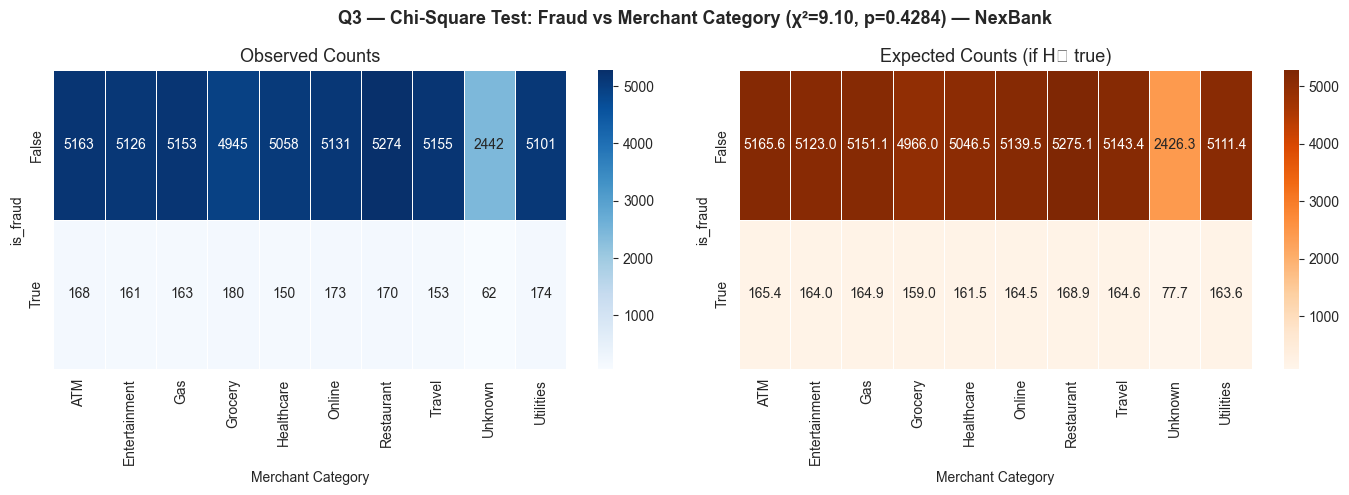

Saved → reports/chi_square_heatmap.png


In [ ]:
# ════════════════════════════════════════════════════════════════
# QUESTION 3 — CHI-SQUARE INDEPENDENCE TEST
# Are fraud rates statistically independent of merchant_category?
# H₀: fraud is independent of merchant_category
# H₁: fraud concentrates in specific merchant categories
# ════════════════════════════════════════════════════════════════
 
if 'is_fraud' in analysis_df.columns and 'merchant_category' in analysis_df.columns:
 
    # Build contingency table: rows = is_fraud, cols = merchant_category
    contingency = pd.crosstab(
        analysis_df['is_fraud'],
        analysis_df['merchant_category']
    )
 
    chi2, p, dof, expected = chi2_contingency(contingency)
 
    print('=' * 55)
    print('  CHI-SQUARE INDEPENDENCE TEST')
    print('=' * 55)
    print(f'  H₀: fraud is independent of merchant_category')
    print(f'  H₁: fraud concentrates in specific categories')
    print()
    print(f'  χ² statistic : {chi2:.4f}')
    print(f'  p-value      : {p:.6f}')
    print(f'  Degrees of freedom: {dof}')
    print()
    if p < 0.05:
        print(f'  RESULT: REJECT H₀ (p={p:.4f} < 0.05)')
        print('  The relationship is statistically significant.')
        print('  Fraud does NOT occur randomly across merchant categories.')
        print('  → Escalate high-rate categories to the risk committee.')
    else:
        print(f'  RESULT: FAIL TO REJECT H₀ (p={p:.4f} ≥ 0.05)')
        print('  No statistically significant relationship detected.')
        print('  → The Q1 groupby pattern may be noise — do not over-interpret.')
    print('=' * 55)
 
    # ── Heatmap: observed vs expected fraud counts ────────────────────────
    expected_df = pd.DataFrame(
        expected,
        index=contingency.index,
        columns=contingency.columns
    ).round(1)
 
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
    sns.heatmap(
        contingency,
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=axes[0],
        linewidths=0.5
    )
    axes[0].set_title('Observed Counts', fontsize=13)
    axes[0].set_xlabel('Merchant Category')
    axes[0].set_ylabel('is_fraud')
 
    sns.heatmap(
        expected_df,
        annot=True,
        fmt='.1f',
        cmap='Oranges',
        ax=axes[1],
        linewidths=0.5
    )
    axes[1].set_title('Expected Counts (if H₀ true)', fontsize=13)
    axes[1].set_xlabel('Merchant Category')
    axes[1].set_ylabel('is_fraud')
 
    plt.suptitle(
        f'Q3 — Chi-Square Test: Fraud vs Merchant Category '
        f'(χ²={chi2:.2f}, p={p:.4f}) — NexBank',
        fontsize=13, fontweight='bold'
    )
    plt.tight_layout()
    plt.savefig(REPORTS_DIR / 'chi_square_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved → reports/chi_square_heatmap.png')
 
 


  ANOMALY DETECTION RESULTS
  HIGH_VALUE anomalies  : 7
    IQR fence           : £-177.10 — £347.78
    Z-score threshold   : |z| > 2
    Consensus required  : both methods must agree

  STEALTH_FRAUD cases   : 1,399
    is_fraud=True but amount within normal range
    These would bypass a simple amount-threshold rule

  Total anomalies saved : 1,406
  Saved → reports/anomalies.csv


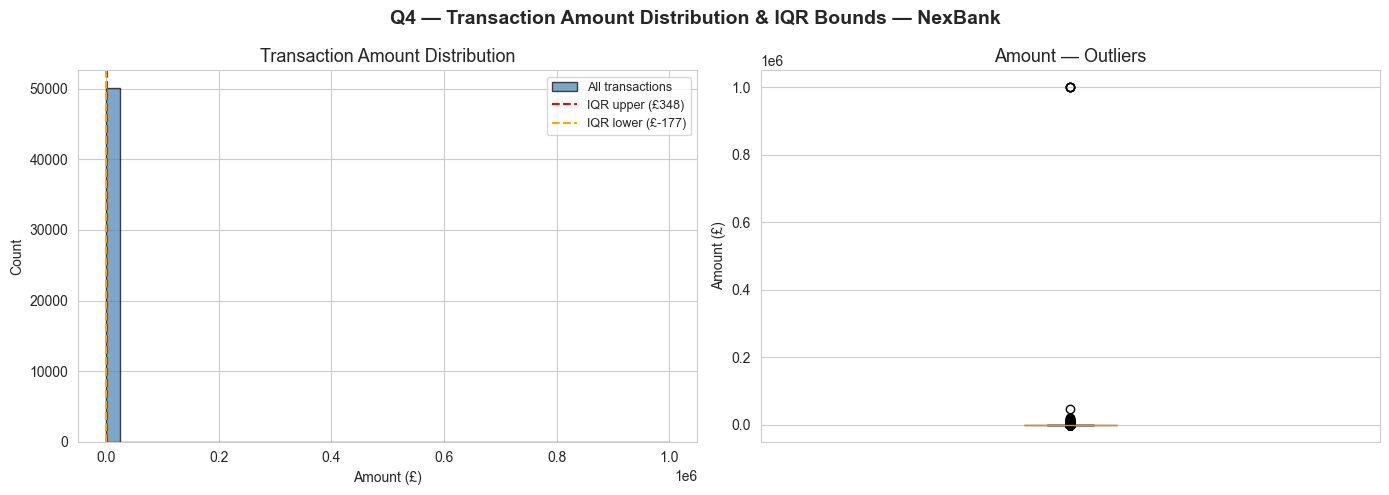

Saved → reports/anomaly_amount_dist.png


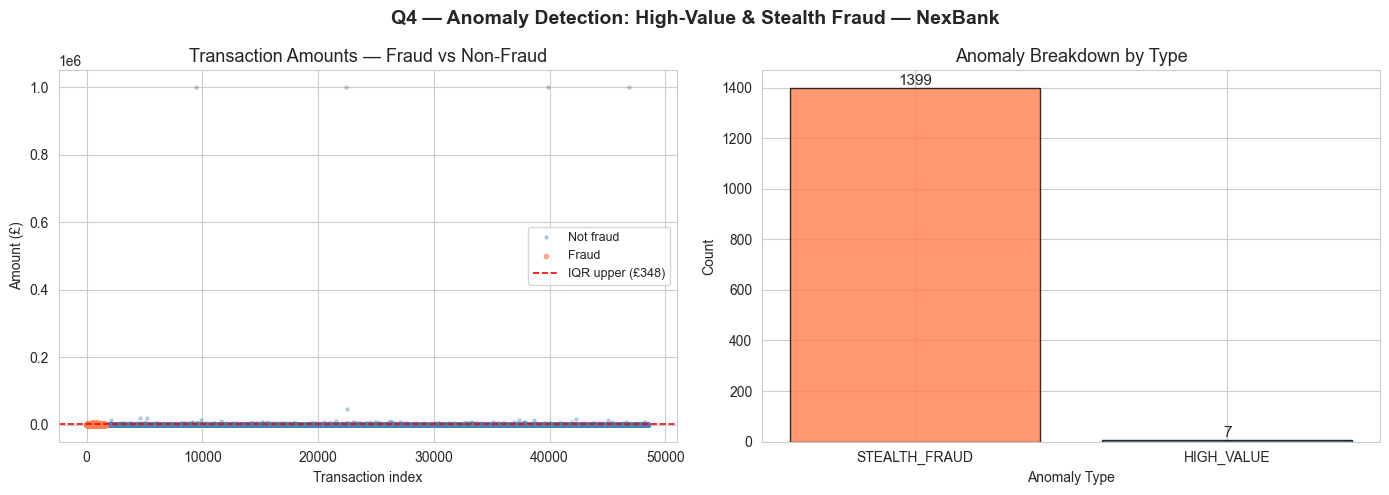

Saved → reports/anomaly_breakdown.png


In [17]:
# ════════════════════════════════════════════════════════════════
# QUESTION 4 — TRANSACTION ANOMALIES
# Flag high-value outliers (IQR + Z-score consensus) AND
# stealth fraud (is_fraud=True but normal amount).
# ════════════════════════════════════════════════════════════════
 
if 'amount' in analysis_df.columns and 'is_fraud' in analysis_df.columns:
 
    # ── IQR bounds ────────────────────────────────────────────────────────
    Q1 = analysis_df['amount'].quantile(0.25)
    Q3 = analysis_df['amount'].quantile(0.75)
    IQR = Q3 - Q1
    iqr_lower = Q1 - 1.5 * IQR
    iqr_upper = Q3 + 1.5 * IQR
 
    iqr_flag = (
        (analysis_df['amount'] < iqr_lower) |
        (analysis_df['amount'] > iqr_upper)
    )
 
    # ── Z-score bounds ────────────────────────────────────────────────────
    # Z-score = (value - mean) / std
    # |z| > 2 means the value is more than 2 standard deviations from the mean
    z_scores = (
        (analysis_df['amount'] - analysis_df['amount'].mean()) /
        analysis_df['amount'].std()
    )
    z_flag = z_scores.abs() > 2
 
    # ── Consensus: both methods must agree ───────────────────────────────
    # This reduces false positives — a transaction must look suspicious
    # under BOTH methods before it is flagged as a high-value anomaly
    high_value = analysis_df[iqr_flag & z_flag].copy()
    high_value['anomaly_type'] = 'HIGH_VALUE'
    high_value['z_score']      = z_scores[iqr_flag & z_flag].round(3)
 
    # ── Stealth fraud: flagged as fraud but amount looks normal ──────────
    # These are the hardest transactions to catch — they do not look
    # suspicious by amount alone. A rules-based system would miss them.
    stealth = analysis_df[
        (analysis_df['is_fraud'] == True) &
        (~iqr_flag) &
        (z_scores.abs() <= 2)
    ].copy()
    stealth['anomaly_type'] = 'STEALTH_FRAUD'
    stealth['z_score']      = z_scores[
        (analysis_df['is_fraud'] == True) &
        (~iqr_flag) &
        (z_scores.abs() <= 2)
    ].round(3)
 
    # ── Combine and save ──────────────────────────────────────────────────
    anomalies = pd.concat([high_value, stealth], ignore_index=True)
    anomalies.to_csv(REPORTS_DIR / 'anomalies.csv', index=False)
 
    print('=' * 55)
    print('  ANOMALY DETECTION RESULTS')
    print('=' * 55)
    print(f'  HIGH_VALUE anomalies  : {len(high_value):,}')
    print(f'    IQR fence           : £{iqr_lower:,.2f} — £{iqr_upper:,.2f}')
    print(f'    Z-score threshold   : |z| > 2')
    print(f'    Consensus required  : both methods must agree')
    print()
    print(f'  STEALTH_FRAUD cases   : {len(stealth):,}')
    print(f'    is_fraud=True but amount within normal range')
    print(f'    These would bypass a simple amount-threshold rule')
    print()
    print(f'  Total anomalies saved : {len(anomalies):,}')
    print(f'  Saved → reports/anomalies.csv')
    print('=' * 55)
 
    # ── Chart 1: Amount distribution with anomaly bounds ─────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
    axes[0].hist(
        analysis_df['amount'].dropna(),
        bins=40,
        color='steelblue',
        alpha=0.7,
        edgecolor='black',
        label='All transactions'
    )
    axes[0].axvline(iqr_upper, color='red',    linestyle='--', linewidth=1.5,
                    label=f'IQR upper (£{iqr_upper:,.0f})')
    axes[0].axvline(iqr_lower, color='orange', linestyle='--', linewidth=1.5,
                    label=f'IQR lower (£{iqr_lower:,.0f})')
    axes[0].set_title('Transaction Amount Distribution', fontsize=13)
    axes[0].set_xlabel('Amount (£)')
    axes[0].set_ylabel('Count')
    axes[0].legend(fontsize=9)
 
    axes[1].boxplot(
        analysis_df['amount'].dropna(),
        vert=True,
        patch_artist=True,
        boxprops=dict(facecolor='steelblue', alpha=0.6)
    )
    axes[1].set_title('Amount — Outliers', fontsize=13)
    axes[1].set_ylabel('Amount (£)')
    axes[1].set_xticks([])
 
    plt.suptitle('Q4 — Transaction Amount Distribution & IQR Bounds — NexBank',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(REPORTS_DIR / 'anomaly_amount_dist.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved → reports/anomaly_amount_dist.png')
 
    # ── Chart 2: Anomaly types — fraud vs normal amount ───────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
    # Scatter: all transactions coloured by fraud flag
    non_fraud = analysis_df[analysis_df['is_fraud'] == False]
    fraud_txns = analysis_df[analysis_df['is_fraud'] == True]
 
    axes[0].scatter(
        range(len(non_fraud)),
        non_fraud['amount'],
        color='steelblue', alpha=0.3, s=5, label='Not fraud'
    )
    axes[0].scatter(
        range(len(fraud_txns)),
        fraud_txns['amount'],
        color='coral', alpha=0.6, s=10, label='Fraud'
    )
    axes[0].axhline(iqr_upper, color='red', linestyle='--', linewidth=1.2,
                    label=f'IQR upper (£{iqr_upper:,.0f})')
    axes[0].set_title('Transaction Amounts — Fraud vs Non-Fraud', fontsize=13)
    axes[0].set_xlabel('Transaction index')
    axes[0].set_ylabel('Amount (£)')
    axes[0].legend(fontsize=9)
 
    # Bar: anomaly type breakdown
    anomaly_counts = anomalies['anomaly_type'].value_counts()
    axes[1].bar(
        anomaly_counts.index,
        anomaly_counts.values,
        color=['coral', 'steelblue'],
        alpha=0.8,
        edgecolor='black'
    )
    axes[1].set_title('Anomaly Breakdown by Type', fontsize=13)
    axes[1].set_xlabel('Anomaly Type')
    axes[1].set_ylabel('Count')
    for i, (label, val) in enumerate(anomaly_counts.items()):
        axes[1].text(i, val + 1, str(val), ha='center', va='bottom', fontsize=11)
 
    plt.suptitle('Q4 — Anomaly Detection: High-Value & Stealth Fraud — NexBank',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(REPORTS_DIR / 'anomaly_breakdown.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved → reports/anomaly_breakdown.png')